# K-Fold cross validation
- hold out (train/test): accuracy depend on how data is split
- k-fold: takes average of different attempts
## steps (easy)
## stratified k-fold (recommended)
- to ensure balance between classes in each fold
## must use pipeline to avoid data leakage

In [ ]:
# k-fold cross validation on breast cancer dataset
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


df = pd.read_csv('https://archive.ics.uci.edu/ml/'
                 'machine-learning-databases'
                 '/breast-cancer-wisconsin/wdbc.data', header=None)

X = df.loc[:, 2:].values
y = df.loc[:, 1].values

# label encoding
le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.20,
                                                    stratify=y,
                                                    random_state=1)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

pipe_lr = make_pipeline(StandardScaler(),
                        PCA(n_components=2),
                        LogisticRegression(random_state=1, solver='lbfgs'))

In [ ]:
from sklearn.model_selection import StratifiedKFold


kfold = StratifiedKFold(n_splits=10).split(X_train, y_train)

scores = []

print('K-Fold through iterations:\n')
for k, (train_idx, val_idx) in enumerate(kfold):
    pipe_lr.fit(X_train[train_idx], y_train[train_idx])

    score = pipe_lr.score(X_train[val_idx], y_train[val_idx])
    scores.append(score)

    print(f'Fold: {k+1:2d}, '
          f'class distribution in Train fold: {np.bincount(y_train[train_idx])}, '
          f'acc: {score:.3f}')

# Kết quả đánh giá cuối cùng là trung bình cộng của 10 folds
print(f'\n=> final CV (Trung bình +/- Độ lệch chuẩn): '
      f'{np.mean(scores):.3f} +/- {np.std(scores):.3f}')

K-Fold through iterations:

Fold:  1, class distribution in Train fold: [256 153], acc: 0.935
Fold:  2, class distribution in Train fold: [256 153], acc: 0.935
Fold:  3, class distribution in Train fold: [256 153], acc: 0.957
Fold:  4, class distribution in Train fold: [256 153], acc: 0.957
Fold:  5, class distribution in Train fold: [256 153], acc: 0.935
Fold:  6, class distribution in Train fold: [257 153], acc: 0.956
Fold:  7, class distribution in Train fold: [257 153], acc: 0.978
Fold:  8, class distribution in Train fold: [257 153], acc: 0.933
Fold:  9, class distribution in Train fold: [257 153], acc: 0.956
Fold: 10, class distribution in Train fold: [257 153], acc: 0.956

=> final CV (Trung bình +/- Độ lệch chuẩn): 0.950 +/- 0.014


In [ ]:
# actually, cross_val_score kinda does this all
from sklearn.model_selection import cross_val_score

scores = cross_val_score(estimator=pipe_lr,
                         X=X_train,
                         y=y_train,
                         cv=10,        # Tự động dùng Stratified K-Fold k=10
                         n_jobs=-1)    # -1 nghĩa là tận dụng toàn bộ số nhân CPU để chạy song song

print(f'Độ chính xác của từng fold: \n{scores}\n')
print(f'=> Độ chính xác CV tổng thể: {np.mean(scores):.3f} +/- {np.std(scores):.3f}')

Độ chính xác của từng fold: 
[0.93478261 0.93478261 0.95652174 0.95652174 0.93478261 0.95555556
 0.97777778 0.93333333 0.95555556 0.95555556]

=> Độ chính xác CV tổng thể: 0.950 +/- 0.014


# Diagnosing Underfitting/Overfitting with Learning Curve
- accuracy over different training data size
- underfitting: increase complexity (add features, reduce regularization)
- overfitting: more data, reduce complexity, or add regularization
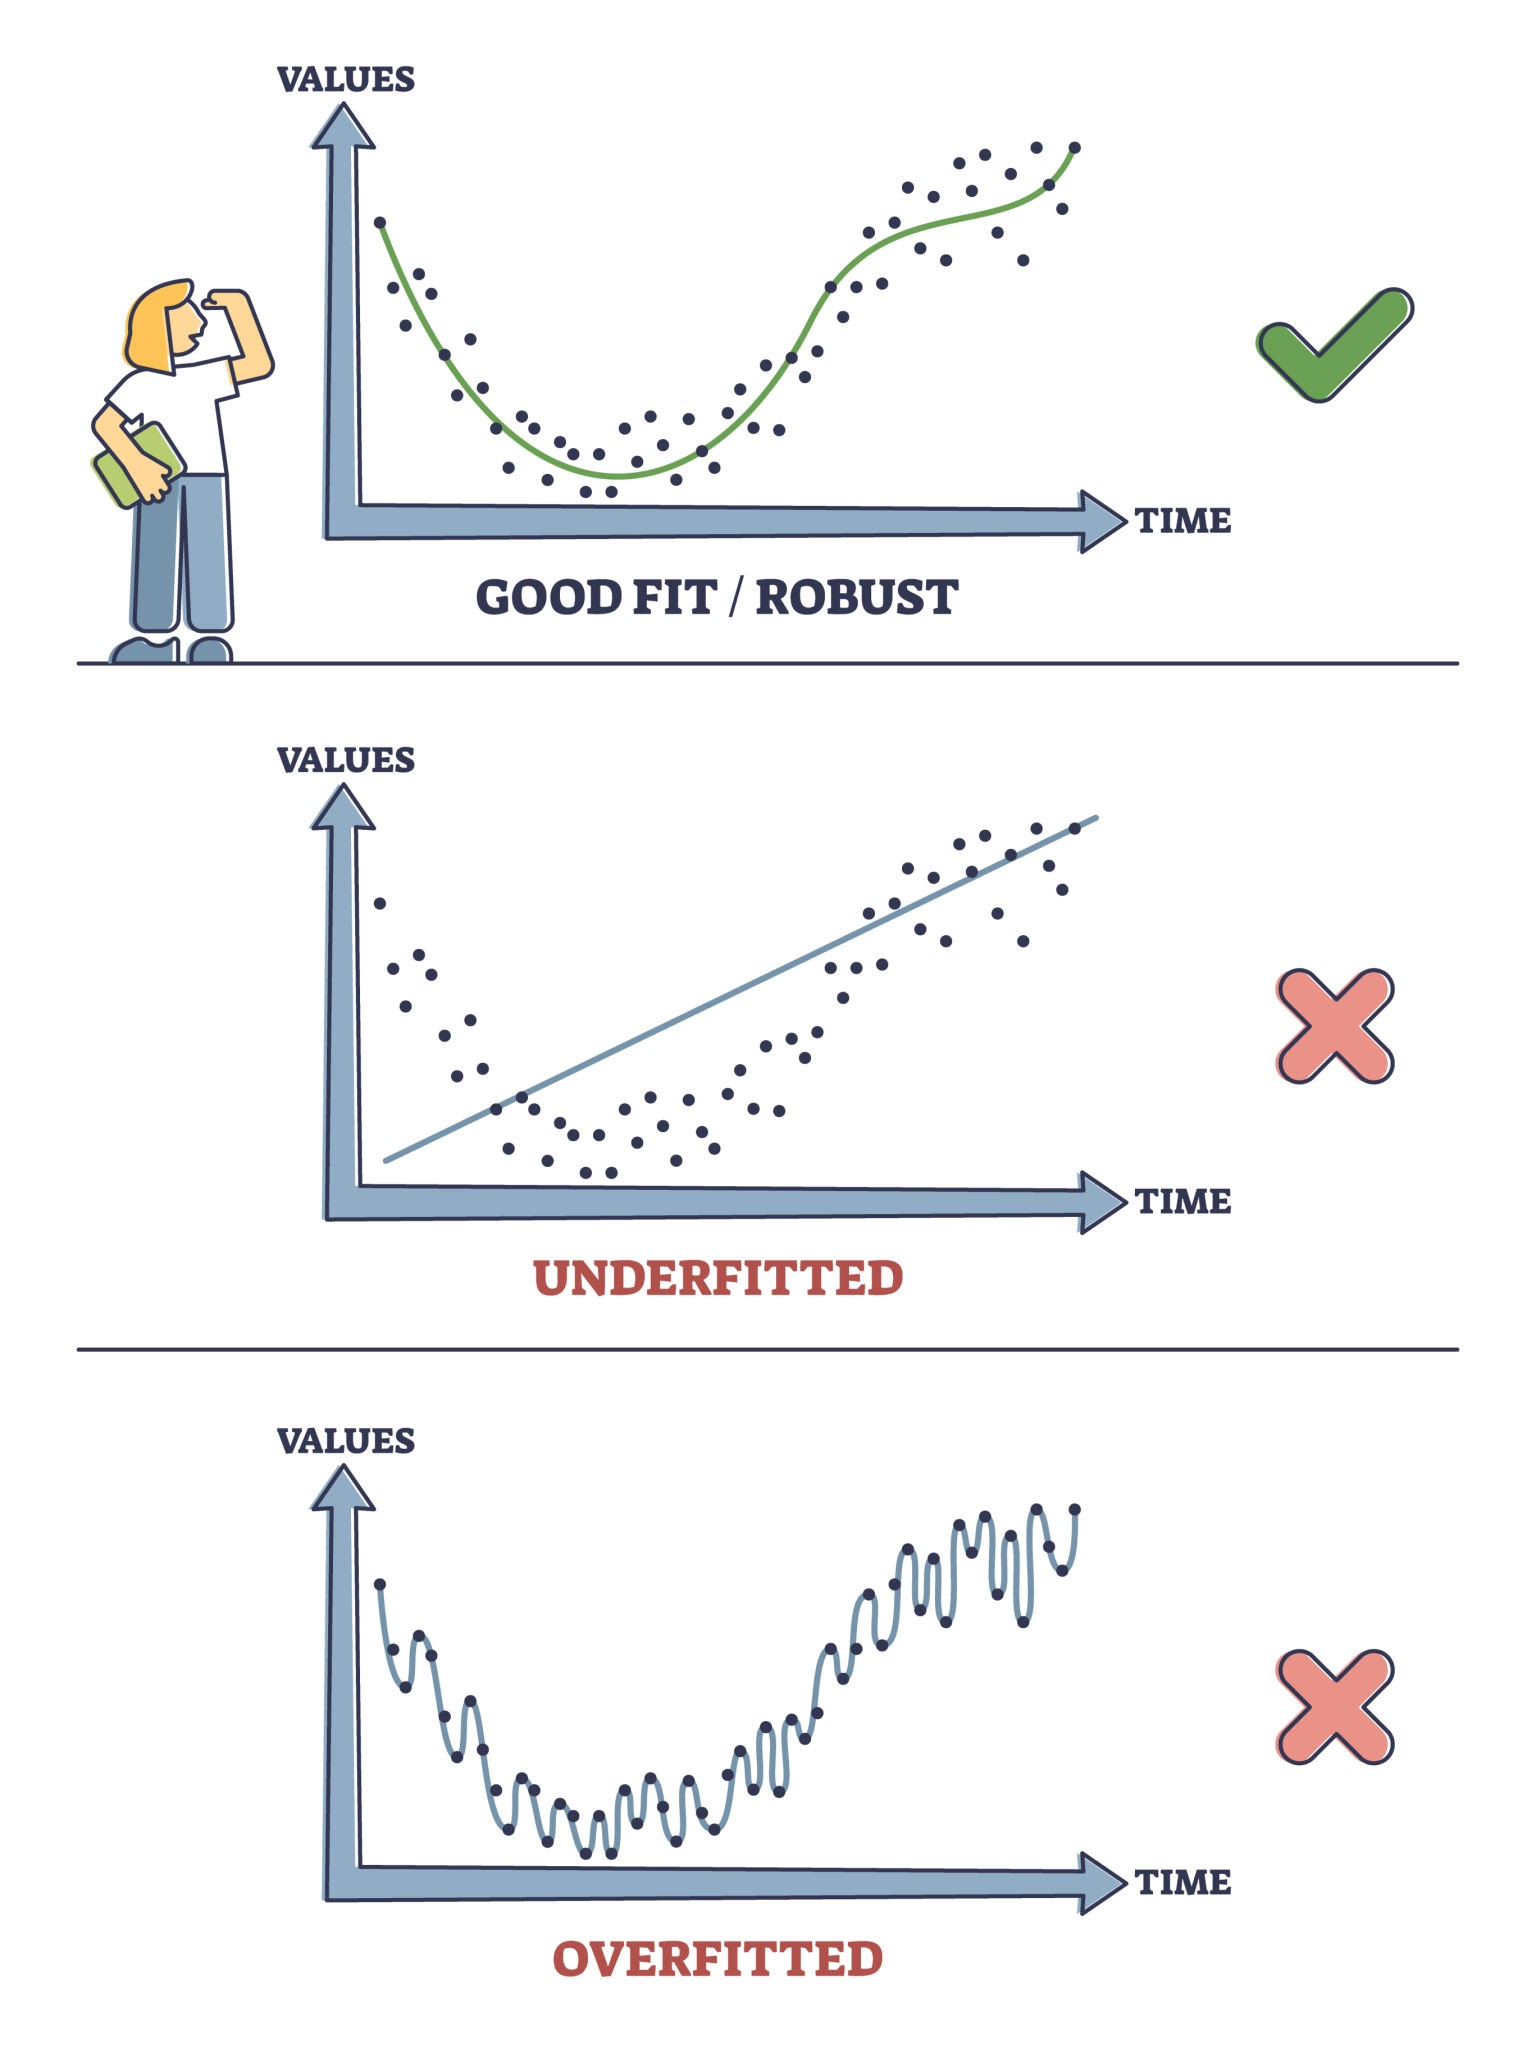

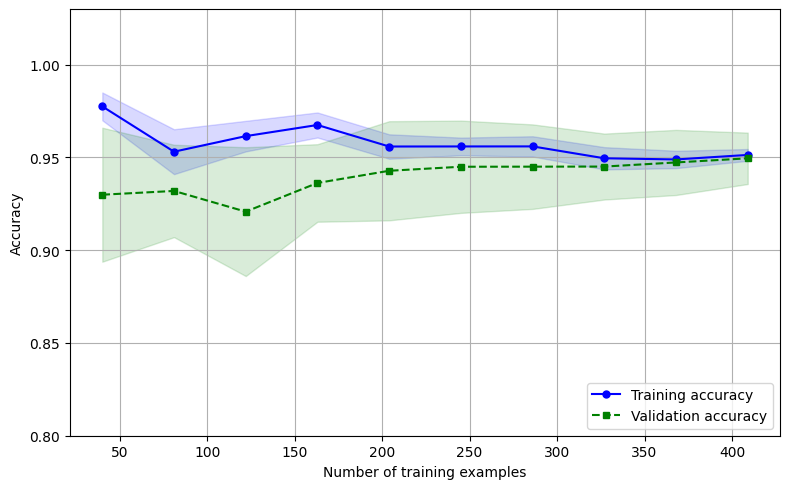

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
                estimator=pipe_lr,
                X=X_train,
                y=y_train,
                train_sizes=np.linspace(0.1, 1.0, 10), # from 10% -> 100%
                cv=10,
                n_jobs=1)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean,
         color='blue', marker='o',
         markersize=5, label='Training accuracy')

plt.fill_between(train_sizes,
                 train_mean + train_std,
                 train_mean - train_std,
                 alpha=0.15, color='blue')

plt.plot(train_sizes, test_mean,
         color='green', linestyle='--',
         marker='s', markersize=5,
         label='Validation accuracy')

plt.fill_between(train_sizes,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='green')

plt.grid()
plt.xlabel('Number of training examples')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.ylim([0.8, 1.03])
plt.tight_layout()
plt.show()

# Addressing overfitting/underfitting with validation curves
 - keep data size same, change value of one hyperparameter.

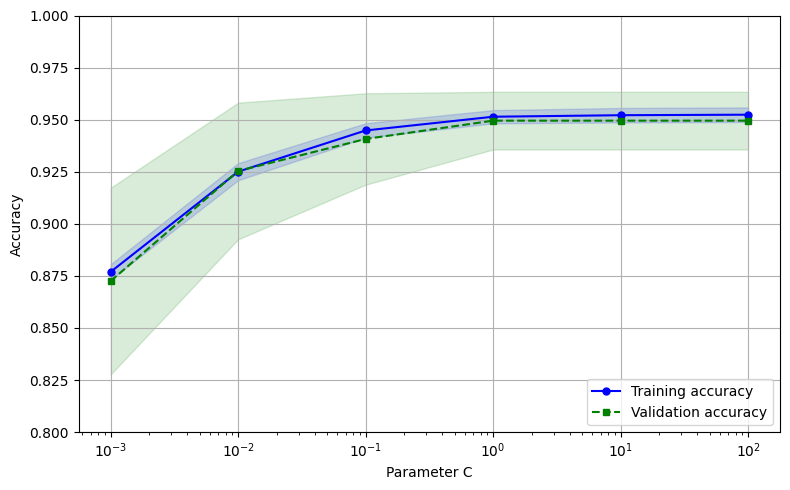

In [ ]:
from sklearn.model_selection import validation_curve

param_range = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

train_scores, test_scores = validation_curve(
                estimator=pipe_lr,
                X=X_train,
                y=y_train,
                param_name='logisticregression__C',
                param_range=param_range,
                cv=10)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(param_range, train_mean,
         color='blue', marker='o',
         markersize=5, label='Training accuracy')
plt.fill_between(param_range, train_mean + train_std,
                 train_mean - train_std, alpha=0.15, color='blue')

plt.plot(param_range, test_mean,
         color='green', linestyle='--',
         marker='s', markersize=5, label='Validation accuracy')
plt.fill_between(param_range, test_mean + test_std,
                 test_mean - test_std, alpha=0.15, color='green')

plt.grid()
plt.xscale('log') # use logarit scale since range is also log_scaled
plt.legend(loc='lower right')
plt.xlabel('Parameter C')
plt.ylabel('Accuracy')
plt.ylim([0.8, 1.0])
plt.tight_layout()
plt.show()

# grid search: find best combinations of multiple hyperparams

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

pipe_svc = make_pipeline(StandardScaler(),
                         SVC(random_state=1))


param_range = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

# block 1:  kernel='linear',  tune  C
# block 2:  kernel='rbf',  tune  C and gamma
param_grid = [{'svc__C': param_range,
               'svc__kernel': ['linear']},
              {'svc__C': param_range,
               'svc__gamma': param_range,
               'svc__kernel': ['rbf']}]

gs = GridSearchCV(estimator=pipe_svc,
                  param_grid=param_grid,
                  scoring='accuracy',
                  cv=10,
                  n_jobs=-1)

gs = gs.fit(X_train, y_train)

print(f'Điểm chính xác CV cao nhất: {gs.best_score_:.3f}')
print(f'Bộ tham số tối ưu: {gs.best_params_}')

Điểm chính xác CV cao nhất: 0.985
Bộ tham số tối ưu: {'svc__C': 100.0, 'svc__gamma': 0.001, 'svc__kernel': 'rbf'}


In [ ]:
# eval best estimator on test set
clf = gs.best_estimator_
clf.fit(X_train, y_train)
print(f'Test accuracy: {clf.score(X_test, y_test):.3f}')

Test accuracy: 0.974


# Nested Cross-Validation
- problem: if using same dataset for training and grid search, we overfit the validation set
- solution: nested CV
- inner loop: divide each fold into training and validation set
- outer loop: k fold as usual
- recomm. setup: 5 outer loop * 2 inner loop

In [ ]:
from sklearn.model_selection import cross_val_score


gs_inner = GridSearchCV(estimator=pipe_svc,
                        param_grid=param_grid,
                        scoring='accuracy',
                        cv=2)

scores_svm = cross_val_score(gs_inner, X_train, y_train,
                             scoring='accuracy', cv=5)

print(f'Nested CV Accuracy (SVM): {np.mean(scores_svm):.3f} +/- {np.std(scores_svm):.3f}')

Nested CV Accuracy (SVM): 0.974 +/- 0.015


In [ ]:
from sklearn.tree import DecisionTreeClassifier

gs_dt = GridSearchCV(estimator=DecisionTreeClassifier(random_state=0),
                     param_grid=[{'max_depth': [1, 2, 3, 4, 5, 6, 7, None]}],
                     scoring='accuracy',
                     cv=2)

scores_dt = cross_val_score(gs_dt, X_train, y_train,
                            scoring='accuracy', cv=5)

print(f'Nested CV Accuracy (Decision Tree): {np.mean(scores_dt):.3f} +/- {np.std(scores_dt):.3f}')

Nested CV Accuracy (Decision Tree): 0.934 +/- 0.016


# Confusion matrix
its hard to understand, im confused too

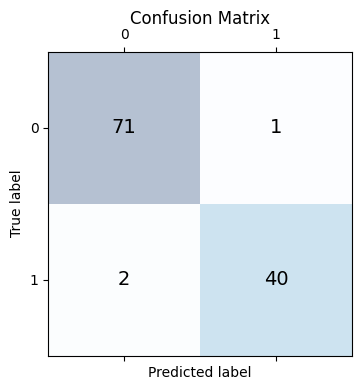

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

pipe_svc.fit(X_train, y_train)

y_pred = pipe_svc.predict(X_test)

confmat = confusion_matrix(y_true=y_test, y_pred=y_pred)

# raschka way of not calling seaborn library
fig, ax = plt.subplots(figsize=(4, 4))
ax.matshow(confmat, cmap=plt.cm.Blues, alpha=0.3)

for i in range(confmat.shape[0]):
    for j in range(confmat.shape[1]):
        ax.text(x=j, y=i, s=confmat[i, j], va='center', ha='center', fontsize=14)

plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix', pad=20)
plt.tight_layout()
plt.show()

# some important metrics
- err = (fp+fn)/(fp+fn+tp+tn)
- acc = (tp+tn)/(fp+fn+tp+tn)
- fpr = fp/n
- tpr = tp/p
- pre = tp/(tp+fp)
- rec = tpr = tp/(fn+tp)
- f1 = 2\*pre\*rec/(pre + rec)

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Tính toán các độ đo trên nhãn Positive (Ác tính = 1)
print(f'Precision: {precision_score(y_true=y_test, y_pred=y_pred):.3f}')
print(f'Recall: {recall_score(y_true=y_test, y_pred=y_pred):.3f}')
print(f'F1-score: {f1_score(y_true=y_test, y_pred=y_pred):.3f}')

Precision: 0.976
Recall: 0.952
F1-score: 0.964


# ROC Curve and AUC
- note: classifiers return probably, then use threshold to decide label (e.g. threshold 0.2 -> recall joinks, precision sad, threshold 0.8 -> precision joinks, recall sad)
- ROC (Receiver Operating Characteristic) represents recall (tpr) and (fpr) as fpr go from 0 to 1
- AUC = 1.0 perfect
- AUC = 0.5 random guessing

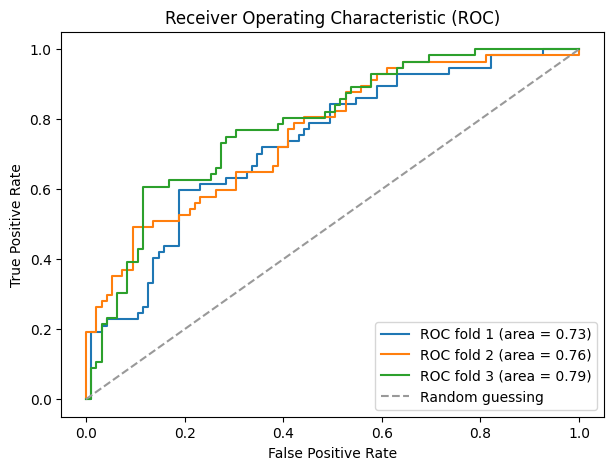

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold

# extract 2 features only
X_train2 = X_train[:, [4, 14]]
X_test2 = X_test[:, [4, 14]]

cv = StratifiedKFold(n_splits=3)
fig = plt.figure(figsize=(7, 5))

mean_tpr = 0.0
mean_fpr = np.linspace(0, 1, 100)
all_tpr = []

for i, (train, test) in enumerate(cv.split(X_train2, y_train)):
    probas = pipe_lr.fit(X_train2[train], y_train[train]).predict_proba(X_train2[test])

    fpr, tpr, thresholds = roc_curve(y_train[test], probas[:, 1], pos_label=1)

    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC fold {i+1} (area = {roc_auc:.2f})')


plt.plot([0, 1], [0, 1], linestyle='--', color=(0.6, 0.6, 0.6), label='Random guessing')

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

# so why imbalances
- Evaluation problem: Accuracy can be misleading. A classifier that always predicts the majority class may achieve very high accuracy while failing completely on the minority class.
- Learning problem: During training, the majority class contributes much more to the loss function, so the model naturally becomes biased toward predicting the majority class unless special techniques (such as resampling, class weighting, or specialized algorithms) are used.
- solutions
  - dont rely on accurarcy alone
  - try class weighting
  - resample training data
  - tune decision threshold
  - stratify splitting and CV
  - eval with confusion matrix